In [4]:
%load_ext autoreload
%autoreload 2

import json, cv2
import numpy as np
from pathlib import Path
from PIL import Image
from IPython.display import Image as IPImage, display
import matplotlib.pyplot as plt

from config import (
    CANVAS_H, CANVAS_W, MARKER_PX, MARGIN, CONTENT_PAD, CONTENT_SCALE,
    TITLE, FPS, DURATION,
    DRAWING_BBOX, MARKER_CENTERS,
    TEMPLATES_DIR, OUTPUT_DIR,
)
from utils import (
    generate_template, overlay_character,
    render_svg, markup_skeleton,
    build_arap_mesh, draw_arap_mesh, animate_arap, preview_motion,
)

# --- что готовим ---
CHAR_ID = "009"

# --- derived ---
CHAR_DIR = TEMPLATES_DIR / CHAR_ID
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Char:    {CHAR_ID} → {CHAR_DIR}  (exists={CHAR_DIR.exists()})")
print(f"Canvas:  {CANVAS_W}×{CANVAS_H}, drawing bbox: {DRAWING_BBOX}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Char:    009 → C:\Users\Luga\Documents\GitHub\ink-to-motion\dev\pipeline\templates\009  (exists=True)
Canvas:  1754×1240, drawing bbox: (150, 150, 1454, 940)


# Empty Template

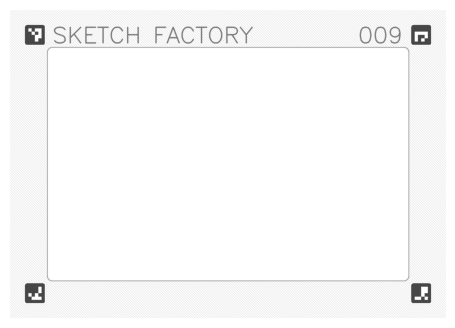

BL marker = 11, label = 009
Сохранено: C:\Users\Luga\Documents\GitHub\ink-to-motion\dev\pipeline\templates\template.png


In [5]:
# BL-маркер кодирует персонажа: 001→3, 002→4, 003→5, ...
BL_ID = int(CHAR_ID) + 2

result = generate_template(
    output_path=str(TEMPLATES_DIR / "template.png"),    # ← в templates/
    canvas_size=(CANVAS_H, CANVAS_W),
    marker_ids=[0, 1, 2, BL_ID],
    marker_px=MARKER_PX,
    margin=MARGIN,
    content_pad=CONTENT_PAD,
    title=TITLE,
    label=CHAR_ID,
)

plt.figure(figsize=(7, 4))
plt.imshow(cv2.cvtColor(result["template"], cv2.COLOR_BGR2RGB))
plt.axis("off"); plt.show()
print(f"BL marker = {BL_ID}, label = {CHAR_ID}")
print(f"Сохранено: {result['template_path']}")

# Наложение персонажа

image_rect: [345, 244, 1064, 752]
Сохранено: C:\Users\Luga\Documents\GitHub\ink-to-motion\dev\pipeline\templates\009\template.png


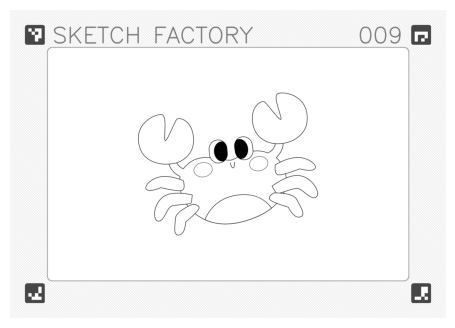

In [6]:
svg_path = CHAR_DIR / "mask.svg"
result_char = overlay_character(
    template_path=str(TEMPLATES_DIR / "template.png"),  # ← оттуда
    svg_path=str(svg_path),
    output_path=str(CHAR_DIR / "template.png"),
    content_scale=CONTENT_SCALE,
)

print(f"image_rect: {result_char['image_rect']}")
print(f"Сохранено: {result_char['output_path']}")

plt.figure(figsize=(7, 4))
plt.imshow(cv2.cvtColor(result_char["template"], cv2.COLOR_BGR2RGB))
plt.axis("off"); plt.show()